№5 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
линейной регрессии. Выполните следующие действия

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "insurance.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "mirichoi0218/insurance",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()

print("First 5 records:", df.head())

C:\Users\lidiya\PycharmProjects\PythonProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


First 5 records:    age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты предсказания

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Контекст данных:
Датасет содержит информацию о пациентах и их расходах на медицинское страхование. Он используется для анализа факторов, влияющих на медицинские расходы, и для построения модели предсказания этих расходов.

| Колонка    | Тип данных | Описание                                                               |
| ---------- | ---------- | ---------------------------------------------------------------------- |
| `age`      | int64      | Возраст пациента (в годах)                                             |
| `sex`      | object     | Пол пациента (`male` / `female`)                                       |
| `bmi`      | float64    | Индекс массы тела (Body Mass Index)                                    |
| `children` | int64      | Количество детей/зависимых                                             |
| `smoker`   | object     | Статус курения (`yes` / `no`)                                          |
| `region`   | object     | Регион проживания (`northeast`, `northwest`, `southeast`, `southwest`) |
| `charges`  | float64    | Годовые медицинские расходы (целевое значение)                         |


Как можно использовать результаты предсказания:

Предсказать будущие медицинские расходы конкретного пациента на основе его характеристик.

Анализировать, какие факторы (например, возраст, курение, индекс массы тела) сильнее всего влияют на расходы.



2. Выберите выходную прогнозируемую переменную.

charges - Годовые медицинские расходы (целевое значение)

3. Постройте линейную регрессионную модель с несколькими значимыми
параметрами (оцените корреляции между признаками, последовательно добавляйте
признаки и сравнивайте качество получаемых моделей, оцените адекватность
модели).

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


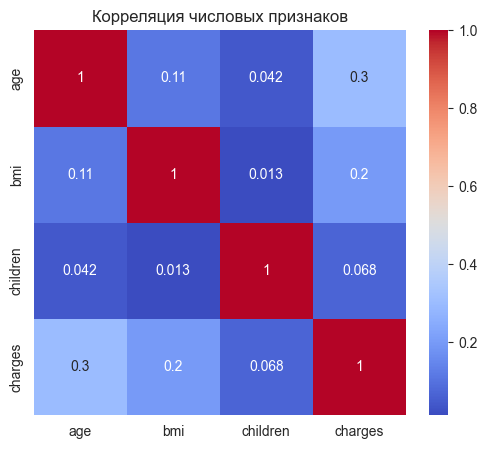

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


import seaborn as sns

df_numeric = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = df_numeric.corr()
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Корреляция числовых признаков")
plt.show()



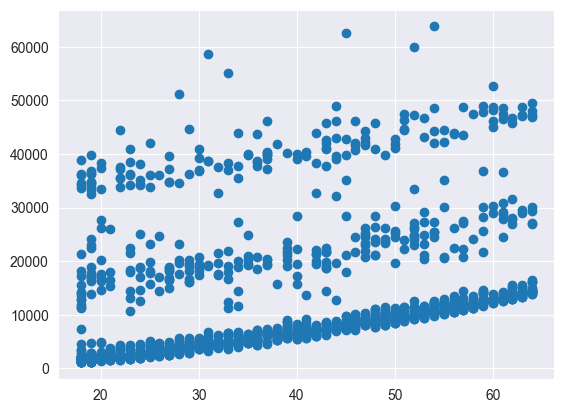

In [7]:
plt.scatter(df['age'], df['charges'])

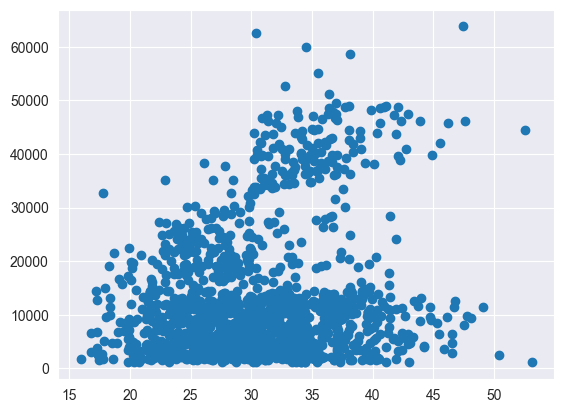

In [8]:
plt.scatter(df['bmi'], df['charges'])

Построим линейную регрессионную модель для возраста

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

X = pd.get_dummies(df.drop('charges', axis=1), drop_first=True)
X_age = X[['age']]
y = df['charges']
X_train_age, X_test_age, y_train, y_test = train_test_split(X_age, y, test_size=0.3, random_state=42)

lr_age = LinearRegression()
lr_age.fit(X_train_age, y_train)

# Получение коэффициентов модели
print(f'Коэффициент наклона (β₁): {lr_age.coef_[0]:.2f}')
print(f'Свободный член (β₀): {lr_age.intercept_:.2f}')

# Делаем предсказания
y_pred_train_age = lr_age.predict(X_train_age)
y_pred_test_age = lr_age.predict(X_test_age)

# Оцениваем качество модели
train_mse = np.sqrt(mean_squared_error(y_train, y_pred_train_age))
test_mse = np.sqrt(mean_squared_error(y_test, y_pred_test_age))
train_r2 = r2_score(y_train, y_pred_train_age)
test_r2 = r2_score(y_test, y_pred_test_age)

print(f'MSE на обучающей выборке: {train_mse:.2f}')
print(f'MSE на тестовой выборке: {test_mse:.2f}')
print(f'R² на обучающей выборке: {train_r2:.4f}')
print(f'R² на тестовой выборке: {test_r2:.4f}')




Коэффициент наклона (β₁): 247.60
Свободный член (β₀): 3673.84
MSE на обучающей выборке: 11586.71
MSE на тестовой выборке: 11474.38
R² на обучающей выборке: 0.0834
R² на тестовой выборке: 0.1020


C:\Users\lidiya\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


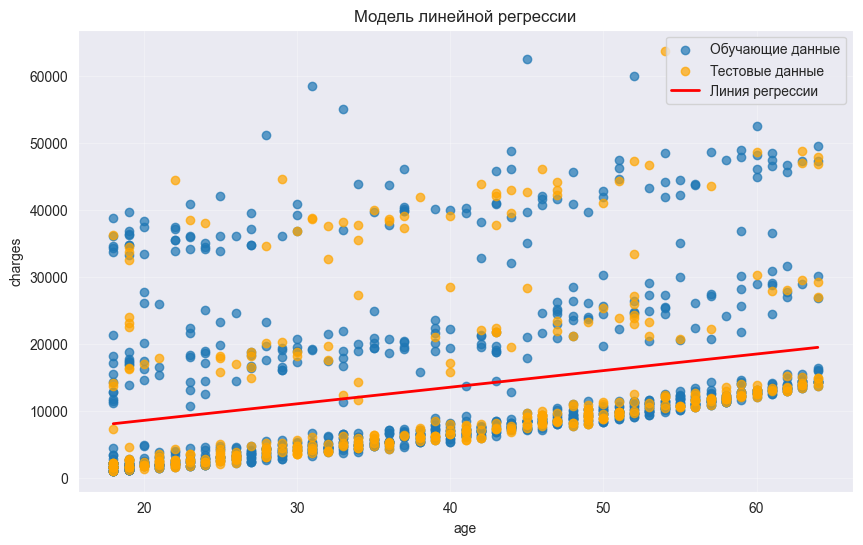

In [12]:
# Создаем диапазон значений для построения линии регрессии
x_range = np.linspace(X['age'].min(), X['age'].max(), 100).reshape(-1, 1)
y_range = lr_age.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_age, y_train, alpha=0.7, label='Обучающие данные')
plt.scatter(X_test_age, y_test, alpha=0.7, color='orange', label='Тестовые данные')
plt.plot(x_range, y_range, color='red', linewidth=2, label='Линия регрессии')
plt.title('Модель линейной регрессии')
plt.xlabel('age')
plt.ylabel('charges')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



Линейная регреccионная модель для BMI

Коэффициент наклона (β₁): 392.30
Свободный член (β₀): 1397.63
MSE на обучающей выборке: 11871.85
MSE на тестовой выборке: 11852.43
R² на обучающей выборке: 0.0377
R² на тестовой выборке: 0.0419


C:\Users\lidiya\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


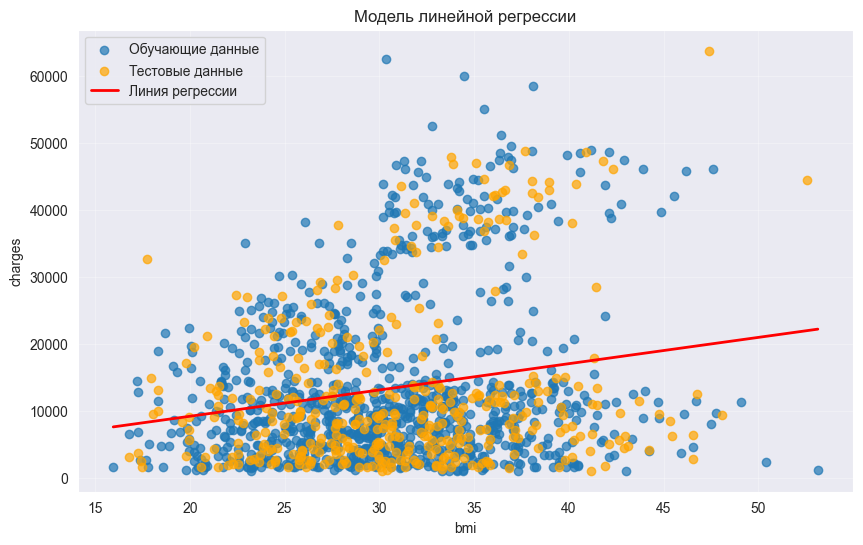

In [16]:

X_bmi = X[['bmi']]
y = df['charges']
X_train_bmi, X_test_bmi, y_train, y_test = train_test_split(X_bmi, y, test_size=0.3, random_state=42)

lr_bmi = LinearRegression()
lr_bmi.fit(X_train_bmi, y_train)

# Получение коэффициентов модели
print(f'Коэффициент наклона (β₁): {lr_bmi.coef_[0]:.2f}')
print(f'Свободный член (β₀): {lr_bmi.intercept_:.2f}')

# Делаем предсказания
y_pred_train_bmi = lr_bmi.predict(X_train_bmi)
y_pred_test_bmi = lr_bmi.predict(X_test_bmi)

# Оцениваем качество модели
train_mse = np.sqrt(mean_squared_error(y_train, y_pred_train_bmi))
test_mse = np.sqrt(mean_squared_error(y_test, y_pred_test_bmi))
train_r2 = r2_score(y_train, y_pred_train_bmi)
test_r2 = r2_score(y_test, y_pred_test_bmi)

print(f'MSE на обучающей выборке: {train_mse:.2f}')
print(f'MSE на тестовой выборке: {test_mse:.2f}')
print(f'R² на обучающей выборке: {train_r2:.4f}')
print(f'R² на тестовой выборке: {test_r2:.4f}')

x_range = np.linspace(X['bmi'].min(), X['bmi'].max(), 100).reshape(-1, 1)
y_range = lr_bmi.predict(x_range)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_bmi, y_train, alpha=0.7, label='Обучающие данные')
plt.scatter(X_test_bmi, y_test, alpha=0.7, color='orange', label='Тестовые данные')
plt.plot(x_range, y_range, color='red', linewidth=2, label='Линия регрессии')
plt.title('Модель линейной регрессии')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()




In [23]:
cols = ['age', 'bmi']
X = X[cols]
print(X.head())

   age     bmi
0   19  27.900
1   18  33.770
2   28  33.000
3   33  22.705
4   32  28.880


Коэффициенты модели:
  Feature  Coefficient
1     bmi   334.046320
0     age   232.515146
Свободный член (Intercept): -5937.2088


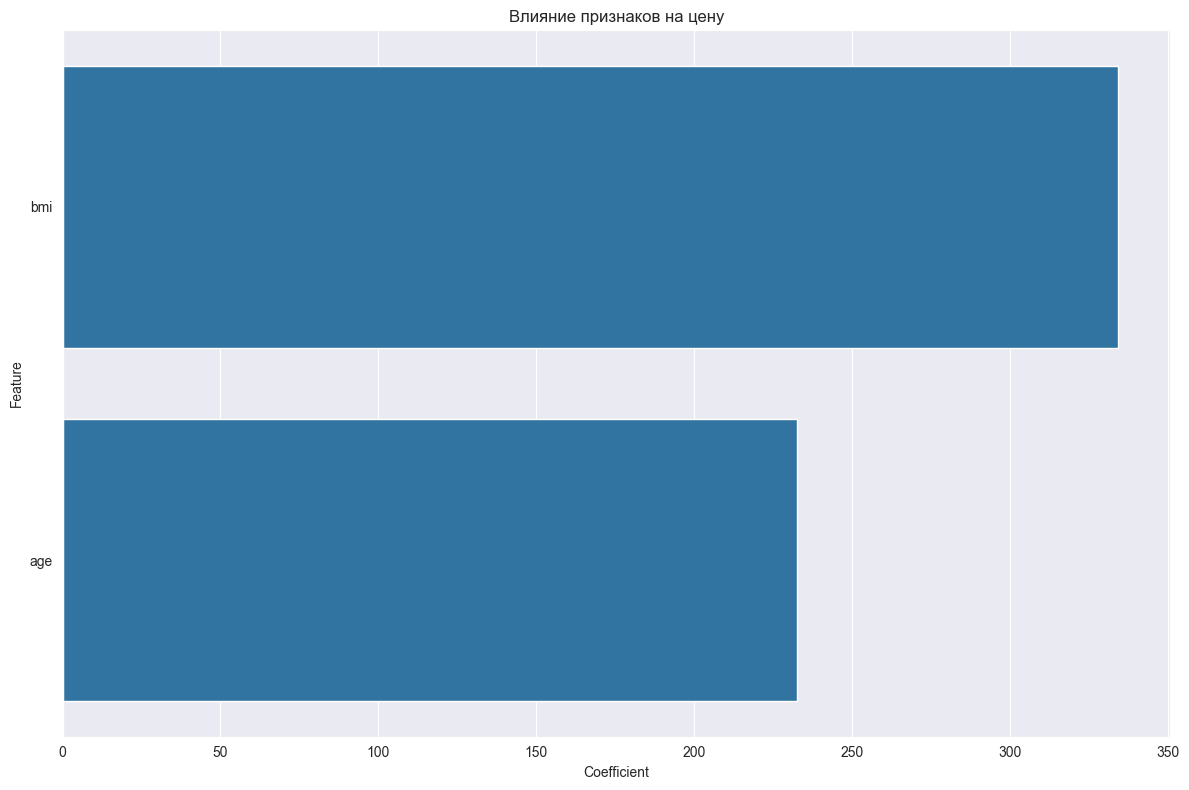

In [26]:
cols = ['age', 'bmi']
X = X[cols]
y = df['charges']

X_train_bmi, X_test_bmi, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr_bmi_age = LinearRegression()
lr_bmi_age .fit(X_train_bmi, y_train)

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_bmi_age .coef_})
coefficients = coefficients.sort_values('Coefficient', ascending=False)
print("Коэффициенты модели:")
print(coefficients)
print(f"Свободный член (Intercept): {lr_bmi_age .intercept_:.4f}")


plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Влияние признаков на цену')
plt.tight_layout()
plt.show()


Интерпретация:

При увеличении возраста на 1 год, расходы в среднем увеличиваются на 232.515146, при фиксированном BMI.

При увеличении BMI на 1 единицу, расходы в среднем увеличиваются на 334.046320, при фиксированном возрасте.

Следовательно, BMI в твоей модели оказывает более сильное влияние, чем возраст.

Оценим качество модели:

In [29]:
# Предсказание на обучающей и тестовой выборках
y_train_pred = lr_bmi_age.predict(X_train_bmi)
y_test_pred = lr_bmi_age.predict(X_test_bmi)

# Расчет метрик качества
train_mse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_mse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"MSE на обучающей выборке: {train_mse:.4f}")
print(f"MSE на тестовой выборке: {test_mse:.4f}")
print(f"R² на обучающей выборке: {train_r2:.4f}")
print(f"R² на тестовой выборке: {test_r2:.4f}")

MSE на обучающей выборке: 11414.4374
MSE на тестовой выборке: 11285.6035
R² на обучающей выборке: 0.1105
R² на тестовой выборке: 0.1314


In [30]:
new_person = pd.DataFrame({
    'age': [40],
    'bmi': [28]
})

prediction = lr_bmi_age.predict(new_person)
print(f"Прогнозируемые медицинские расходы: {prediction[0]:.2f}")


Прогнозируемые медицинские расходы: 12716.69


В результате построения линейной регрессионной модели была получена зависимость медицинских расходов от возраста и индекса массы тела. Оба признака оказывают положительное влияние на величину расходов. Наибольший вклад в модель вносит показатель BMI, так как его коэффициент больше, чем у возраста.

Динейная регрессия по признаку smoker

In [33]:
# Кодируем столбец smoker: yes = 1, no = 0
df['smoker_num'] = df['smoker'].map({'yes': 1, 'no': 0})

X_smoker = df[['smoker_num']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X_smoker, y, test_size=0.3, random_state=42
)
lr_smoker = LinearRegression()
lr_smoker.fit(X_train, y_train)
print(f"Коэффициент (β₁): {lr_smoker.coef_[0]:.2f}")
print(f"Свободный член (β₀): {lr_smoker.intercept_:.2f}")

y_train_pred = lr_smoker.predict(X_train)
y_test_pred = lr_smoker.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"RMSE (обучение): {train_rmse:.2f}")
print(f"RMSE (тест): {test_rmse:.2f}")
print(f"R² (обучение): {train_r2:.4f}")
print(f"R² (тест): {test_r2:.4f}")




Коэффициент (β₁): 23214.15
Свободный член (β₀): 8542.88
RMSE (обучение): 7588.66
RMSE (тест): 7173.79
R² (обучение): 0.6068
R² (тест): 0.6490


R² ≈ 0.60–0.65

Это значит, что факт курения объясняет около 60–65% всех медицинских затрат

In [34]:
new_people = pd.DataFrame({
    'smoker_num': [0, 1]
})

predictions = lr_smoker.predict(new_people)

new_people['predicted_charges'] = predictions
print(new_people)


   smoker_num  predicted_charges
0           0        8542.875189
1           1       31757.029354


В результате построения линейной регрессионной модели по признаку «курение» было установлено, что курящие пациенты в среднем тратят на медицинские услуги значительно больше, чем некурящие. Коэффициент при признаке «smoker» имеет большое положительное значение, а коэффициент детерминации R² превышает 0.6, что указывает на сильное влияние курения на величину медицинских расходов.

№6 (3 балла)
Различные метрики качества реализованы в пакете sklearn.metrics. Подробнее о них
смотрите в лекции или в учебных пособиях, например, https://github.com/esokolov/mlcourse-msu/blob/master/ML15/lecture-notes/Sem05_metrics.pdf.
1. Загрузите файл classification.csv (https://cloud.mail.ru/public/QGde/JFrAntvih). В нем
записаны истинные классы объектов выборки (колонка true) и ответы некоторого
классификатора (колонка predicted).
2. Заполните таблицу ошибок классификации: <br>
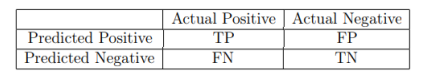 <br>
Для этого подсчитайте величины TP, FP, FN и TN согласно их определениям.
Например, FP — это количество объектов, имеющих класс 0, но отнесенных
алгоритмом к классу 1.
3. Посчитайте основные метрики качества классификатора:
a. Accuracy (доля верно угаданных) — sklearn.metrics.accuracy
b. Precision (точность) — sklearn.metrics.accuracy.precision_score
c. Recall (полнота) — sklearn.metrics.re

In [38]:
from sklearn.metrics import *

df = pd.read_csv('classification.csv')
cm = confusion_matrix(df['true'], df['pred'])
tn, fp, fn, tp = cm.ravel()
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")

True Positives (TP): 43
True Negatives (TN): 64
False Positives (FP): 34
False Negatives (FN): 59


|                     | Actual Positive | Actual Negative |
|---------------------|-----------------|-----------------|
| **Predicted Positive** | TP = 43         | FP = 34         |
| **Predicted Negative** | FN = 59         | TN = 64         |

In [53]:
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score

accuracy = accuracy_score(df['true'], df['pred'])
precision = precision_score(df['true'], df['pred'])
recall = recall_score(df['true'], df['pred'])
f1 = f1_score(df['true'], df['pred'])
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F-мера : {f1:.2f}")

Accuracy: 0.54
Precision: 0.56
Recall: 0.42
F-мера : 0.48


№7 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
логистической регрессии (задача классификации). Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты классификации.
2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.
3. Спрогнозируйте несколько новых значений с помощью построенной модели.

В работе используется набор данных Heart Disease Dataset, содержащий медицинские сведения о пациентах и предназначенный для решения задачи бинарной классификации — определения наличия сердечно-сосудистого заболевания у пациента.

In [54]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "johnsmith88/heart-disease-dataset",
  file_path,

)

print("First 5 records:", df.head())

100%|██████████| 37.2k/37.2k [00:00<00:00, 544kB/s]

First 5 records:    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [55]:
df.info

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

Состав данных <br>

Каждая строка набора данных соответствует одному пациенту и содержит следующие основные признаки:

* age — возраст пациента
* sex — пол (0 — женщина, 1 — мужчина)
* cp — тип боли в груди
* trestbps — артериальное давление в состоянии покоя
* chol — уровень холестерина
* fbs — уровень сахара в крови натощак
* restecg — результаты электрокардиограммы в покое
* thalach — максимальная достигнутая частота сердечных сокращений
* exang — наличие стенокардии при физической нагрузке
* oldpeak — депрессия сегмента ST при нагрузке
* slope — наклон сегмента ST
* ca — количество крупных сосудов
* thal — тип дефекта кровоснабжения
* target — целевая переменная (0 — отсутствует заболевание, 1 — заболевание присутствует)

Использование результатов классификации

Результаты, полученные с помощью логистической регрессии, могут использоваться в следующих целях:

для предварительной медицинской диагностики пациентов;

для выявления групп повышенного риска развития сердечно-сосудистых заболеваний;

для поддержки решений врачей при направлении пациентов на дополнительные обследования;

для анализа влияния различных факторов риска (возраст, давление, холестерин и др.) на вероятность заболевания.

Распределение по классам

In [56]:
class_counts = df['target'].value_counts()
print(class_counts)

target
1    526
0    499
Name: count, dtype: int64


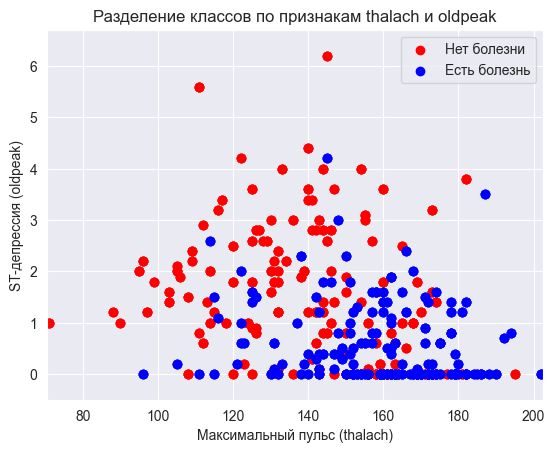

In [70]:

filtered_df = df.copy()
class1_data = filtered_df[filtered_df['target'] == 1]
class0_data = filtered_df[df['target'] == 0]

xmin, xmax = filtered_df['thalach'].min() - 0.5, filtered_df['thalach'].max() + 0.5
ymin, ymax = filtered_df['oldpeak'].min() - 0.5, filtered_df['oldpeak'].max() + 0.5
class1_color = 'blue'
class0_color = 'red'

plt.scatter(class0_data['thalach'], class0_data['oldpeak'], label='Нет болезни', c=class0_color)
plt.scatter(class1_data['thalach'], class1_data['oldpeak'], label='Есть болезнь', c=class1_color)

plt.xlabel('Максимальный пульс (thalach)')
plt.ylabel('ST-депрессия (oldpeak)')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.title('Разделение классов по признакам thalach и oldpeak')
plt.legend()
plt.grid(True)
plt.show()

Для визуального анализа задачи классификации были выбраны признаки thalach (максимальная частота сердечных сокращений) и oldpeak (депрессия сегмента ST). Данные признаки обеспечивают наилучшее визуальное разделение классов. На графике видно, что у пациентов с заболеванием сердца значения oldpeak в среднем выше, а thalach — ниже, чем у здоровых пациентов.

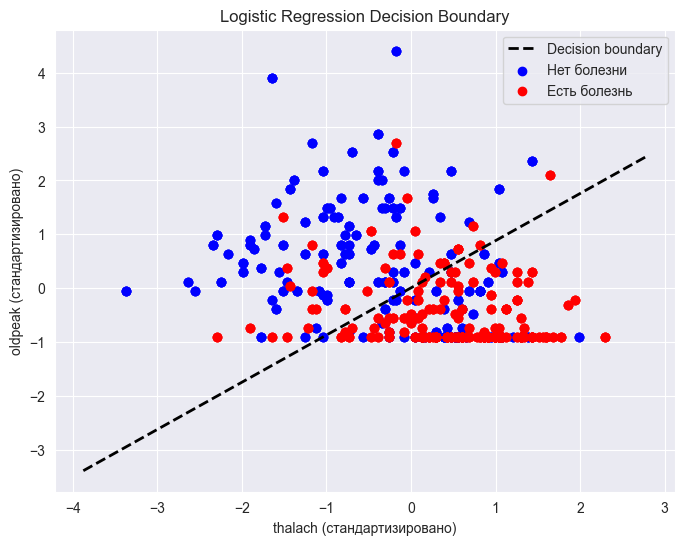

In [96]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

# Выбираем только 2 признака для визуализации
X_plot = filtered_df[['thalach', 'oldpeak']]
y_plot = filtered_df['target']

# Стандартизируем
scaler = StandardScaler()
X_plot_scaled = scaler.fit_transform(X_plot)

# Обучаем логистическую регрессию на 2 признаках
logreg = LogisticRegression(solver='liblinear', max_iter=1000)
logreg.fit(X_plot_scaled, y_plot)

# Коэффициенты модели
b = logreg.intercept_[0]
w1, w2 = logreg.coef_[0]
m = -w1 / w2
c = -b / w2

# Разделяем классы
class0_data = X_plot_scaled[y_plot==0]
class1_data = X_plot_scaled[y_plot==1]

# Границы графика
xmin, xmax = X_plot_scaled[:,0].min() - 0.5, X_plot_scaled[:,0].max() + 0.5
xd = np.array([xmin, xmax])
yd = m*xd + c


plt.figure(figsize=(8,6))
plt.plot(xd, yd, 'k--', lw=2, label='Decision boundary')
plt.scatter(class0_data[:,0], class0_data[:,1], label='Нет болезни', c='blue')
plt.scatter(class1_data[:,0], class1_data[:,1], label='Есть болезнь', c='red')
plt.xlabel('thalach (стандартизировано)')
plt.ylabel('oldpeak (стандартизировано)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()



In [102]:
y_pred = logreg.predict(X_plot_scaled)
cm = confusion_matrix(y_plot, y_pred)
print(f'Confusion Matrix: \n{cm}')

Confusion Matrix: 
[[324 168]
 [112 408]]


True Negative (TN) = 324 → правильно определили здоровых

False Positive (FP) = 168 → здоровых ошибочно отнесли к больным

False Negative (FN) = 112 → больных ошибочно отнесли к здоровым

True Positive (TP) = 408 → правильно определили больных

In [110]:
accuracy = accuracy_score(y_plot, y_pred)
precision = precision_score(y_plot, y_pred)
recall = recall_score(y_plot, y_pred)
f1 = f1_score(y_plot, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")


Accuracy: 0.72
Precision: 0.71
Recall: 0.78
F1-score: 0.74


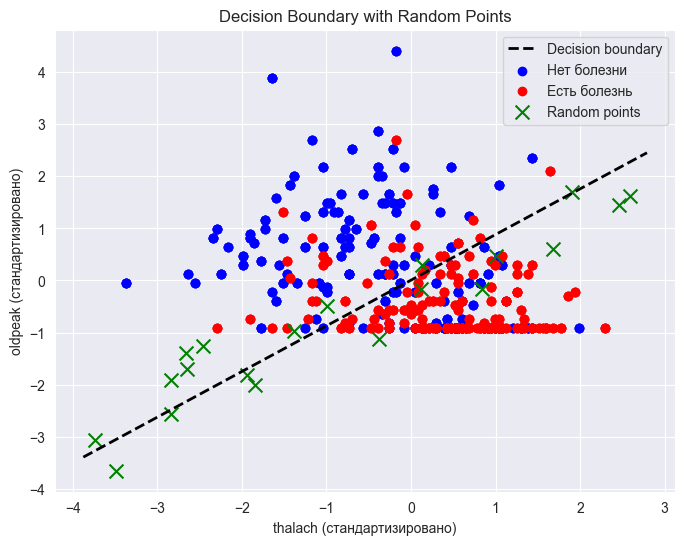

Random point 1: predicted class = 0
Random point 2: predicted class = 1
Random point 3: predicted class = 1
Random point 4: predicted class = 1
Random point 5: predicted class = 1
Random point 6: predicted class = 0
Random point 7: predicted class = 1
Random point 8: predicted class = 0
Random point 9: predicted class = 0
Random point 10: predicted class = 1
Random point 11: predicted class = 0
Random point 12: predicted class = 1
Random point 13: predicted class = 1
Random point 14: predicted class = 0
Random point 15: predicted class = 0
Random point 16: predicted class = 0
Random point 17: predicted class = 1
Random point 18: predicted class = 1
Random point 19: predicted class = 0
Random point 20: predicted class = 1


In [113]:
import numpy as np
import matplotlib.pyplot as plt

# Коэффициенты модели
b = logreg.intercept_[0]
w1, w2 = logreg.coef_[0]
m = -w1 / w2
c = -b / w2

# Создание линии (decision boundary) для наглядности
xmin, xmax = X_plot_scaled[:,0].min() - 0.5, X_plot_scaled[:,0].max() + 0.5
xd = np.linspace(xmin, xmax, 100)
yd = m*xd + c

# Генерация случайных точек в окрестности гиперплоскости
num_points = 20
np.random.seed(42)
x_rand = np.random.uniform(xmin, xmax, num_points)
y_rand = m*x_rand + c + np.random.uniform(-1, 1, num_points)  # небольшое смещение по y
random_points = np.column_stack((x_rand, y_rand))

# Предсказание класса для случайных точек
pred_classes = logreg.predict(random_points)

plt.figure(figsize=(8,6))
# Decision boundary
plt.plot(xd, yd, 'k--', lw=2, label='Decision boundary')
# Исходные классы
plt.scatter(class0_data[:,0], class0_data[:,1], label='Нет болезни', c='blue')
plt.scatter(class1_data[:,0], class1_data[:,1], label='Есть болезнь', c='red')
# Случайные точки
plt.scatter(random_points[:,0], random_points[:,1], label='Random points', c='green', marker='x', s=100)

plt.xlabel('thalach (стандартизировано)')
plt.ylabel('oldpeak (стандартизировано)')
plt.title('Decision Boundary with Random Points')
plt.legend()
plt.grid(True)
plt.show()

for i, cls in enumerate(pred_classes):
    print(f"Random point {i+1}: predicted class = {cls}")
